# MLS211 Report Data Reader

## Task 1a

In [ ]:
# Import all necessary libraries
# Do this here so it is not necessary to run all sections sequentially
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

from mls211 import (
    ExcelWriter,
    StandardCurveAnalyser,
    StandardCurveBuilder,
    round_half_up,
)




In [2]:
# Read the copied task 1a data

DEFAULT_EXCEL_FILE = "./Task 1a/Task 1a.xlsx"

# S_Mean is the mean value submitted by the student
# S_Blanked is the blanked value submitted by the student
colnames = ["ID","Conc","Abs1", "Abs2", "S_Mean", "S_Blanked"]

# Copy submitted results to here
input_text = """
B 0.0 0.117 0.099 0.108 0.0
S1 0.1 0.245 0.263 0.254 0.146
S2 0.2 0.448 0.443 0.445 0.337
S3 0.5 1.020 1.045 1.032 0.924
S4 0.8 1.590 1.613 1.613 1.505
S5 1.0 2.013 2.036 2.024 1.916
"""

builder = StandardCurveBuilder()
df = builder.read(input_text.strip()).set_colnames(colnames).calc_abs_means(["Abs1", "Abs2"]).build()
analyser = StandardCurveAnalyser(df)
reg = analyser.linear_regression("Conc","Blanked_Abs")
r_squared = analyser.r_squared_forced_through_origin("Conc", "Blanked_Abs")

# Calculate concentration based on given absorbance
da_abs = 0.752
da_dilution = 5
da_conc = da_dilution*da_abs/reg[0]
# Round mean and blanked absorbances just prior to printing
# Round exactly to three decimal places
df['Mean_Abs'] = round_half_up(df['Mean_Abs'], "0.001")
df['Blanked_Abs'] = round_half_up(df['Blanked_Abs'], "0.001")
# Print output
print(df)
print(f"Slope: {reg[0]:.4f}, Intercept: {reg[1]:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Conc of unknown (abs={da_abs:.3f}): {da_conc:.1f} mmol/L")


   ID  Conc   Abs1   Abs2  S_Mean  S_Blanked Mean_Abs Blanked_Abs
0   B   0.0  0.117  0.099   0.108      0.000    0.108       0.000
1  S1   0.1  0.245  0.263   0.254      0.146    0.254       0.146
2  S2   0.2  0.448  0.443   0.445      0.337    0.446       0.338
3  S3   0.5  1.020  1.045   1.032      0.924    1.033       0.925
4  S4   0.8  1.590  1.613   1.613      1.505    1.602       1.494
5  S5   1.0  2.013  2.036   2.024      1.916    2.024       1.916
Slope: 1.8844, Intercept: 0.0000
R-squared: 0.9993
Conc of unknown (abs=0.752): 2.0 mmol/L


In [ ]:
# Write to Excel
writer = ExcelWriter()
excel_output_path = DEFAULT_EXCEL_FILE
raw_data = df.iloc[:, [2,3]]
writer.write_dataframe_to_excel(raw_data, pathlib.Path(excel_output_path), "Table 3", 3, 6)
print(f"Data written to Excel file: {excel_output_path}")

## Task 1b

### Table 1 Glucose

Standard Curve
   ID  Conc   Abs1   Abs2  S_Mean  S_Blanked Mean_Abs Blanked_Abs
0  RB   0.0  0.086  0.091   0.089      0.000    0.089       0.000
1  S1   0.1  0.286  0.302   0.294      0.206    0.294       0.206
2  S2   0.2  0.487  0.486   0.487      0.398    0.487       0.398
3  S3   0.5  1.062  1.083   1.073      0.984    1.073       0.984
4  S4   0.8  1.690  1.704   1.697      1.609    1.697       1.609
5  S5   1.0  2.091  2.146   2.119      2.030    2.119       2.030
Slope: 2.0149, Intercept: 0.0000
R-squared: 0.9999


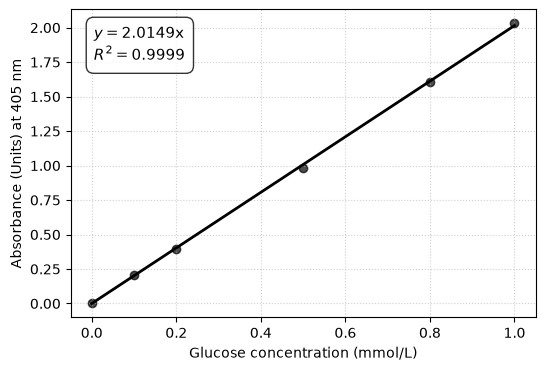

Samples
       ID  Conc   Abs1   Abs2  S_Mean  S_Blanked Mean_Abs Blanked_Abs
0    P1-F   5.8  0.805  0.820   0.813      0.724    0.813       0.724
1   P1-60  13.6  1.776  1.812   1.794      1.705    1.794       1.706
2  P1-120   9.3  1.224  1.297   1.261      1.172    1.261       1.172
3    P2-F   7.5  1.019  1.036   1.028      0.939    1.027       0.939
4  P2-120  11.5  1.539  1.527   1.533      1.444    1.533       1.445
5      QC   5.9  0.836  0.823   0.830      0.741    0.829       0.741


In [3]:
# S_Mean is the mean value submitted by the student
# S_Blanked is the blanked value submitted by the student
colnames = ["ID","Conc","Abs1", "Abs2", "S_Mean", "S_Blanked"]

sample_dilution_factor = 16.01

# Absorbances for standard curve
std_data = """
RB 0.0 0.086 0.091 0.089 0.000
S1 0.1 0.286 0.302 0.294 0.206
S2 0.2 0.487 0.486 0.487 0.398
S3 0.5 1.062 1.083 1.073 0.984
S4 0.8 1.690 1.704 1.697 1.609
S5 1.0 2.091 2.146 2.119 2.030
"""

sample_data = """
P1-F Unknown 0.805 0.820 0.813 0.724
P1-60 Unknown 1.776 1.812 1.794 1.705
P1-120 Unknown 1.224 1.297 1.261 1.172
P2-F Unknown 1.019 1.036 1.028 0.939
P2-120 Unknown 1.539 1.527 1.533 1.444
QC Unknown 0.836 0.823 0.830 0.741
"""

builder = StandardCurveBuilder()
df = builder.read(std_data.strip()).set_colnames(colnames).calc_abs_means(["Abs1", "Abs2"]).build()
analyser = StandardCurveAnalyser(df)
reg = analyser.linear_regression("Conc","Blanked_Abs")
r_squared = analyser.r_squared_forced_through_origin("Conc", "Blanked_Abs")

df_samples = builder.read(sample_data.strip()).set_colnames(colnames).calc_abs_means(["Abs1", "Abs2"]).build()

df_samples = analyser.calculate_sample_concentration(df_samples,"Conc","Blanked_Abs", sample_dilution_factor)

# Round data prior to printing
df['Mean_Abs'] = round_half_up(df['Mean_Abs'], "0.001")
df['Blanked_Abs'] = round_half_up(df['Blanked_Abs'], "0.001")

x = df["Conc"]
y = df['Blanked_Abs']
trendline = x * reg[0]
# Create scatter chart
# Create the plot
plt.figure(figsize=(6, 4))

# Plot the scatter points
plt.scatter(x, y, color="black", alpha=0.7, label="Data Points")

# Plot the trendline
plt.plot(
    x, trendline, color="black", linestyle="-", linewidth=2, label="Trendline"
)

equation_text = (
    f"$y = {reg[0]:.4f}$x\n$R^2 = {r_squared:.4f}$"
)

# Place text using axes coordinates (transform=ax.transAxes) so it stays fixed
# (0.05, 0.95 is top-left; 0.95, 0.05 is bottom-right)
plt.gca().text(
    0.05,
    0.95,
    equation_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox={"boxstyle": "round, pad=0.5", "facecolor": "white", "alpha": 0.8},
)

# 5. Customize the chart
plt.xlabel("Glucose concentration (mmol/L)")
plt.ylabel("Absorbance (Units) at 405 nm")
plt.grid(True, linestyle=":", alpha=0.6)


print("Standard Curve")
print(df)
print(f"Slope: {reg[0]:.4f}, Intercept: {reg[1]:.4f}")
print(f"R-squared: {r_squared:.4f}")

# Display the plot
plt.show()

df_samples['Mean_Abs'] = round_half_up(df_samples['Mean_Abs'], "0.001")
df_samples['Blanked_Abs'] = round_half_up(df_samples['Blanked_Abs'], "0.001")
print("Samples")
print(df_samples)

In [ ]:
# Write to Task1b.xlsx
writer = ExcelWriter()
excel_output_path = "./Task 1b/Task1b.xlsx"
raw_data = df.iloc[:, [2,3]]
writer.write_dataframe_to_excel(raw_data, pathlib.Path(excel_output_path),"Sheet1", 3, 6)


raw_data_samples = df_samples.iloc[:, [2,3]]
writer.write_dataframe_to_excel(raw_data_samples, pathlib.Path(excel_output_path),"Sheet1", 3, 13)

df_slope = pd.DataFrame([reg[0]], columns=["Gradient"])
writer.write_dataframe_to_excel(df_slope, pathlib.Path(excel_output_path),"Sheet1", 6, 22)

print(f"Data written to Excel file: {excel_output_path}")

### Table 2: Cholesterol

In [4]:
# Convert text to pandas dataframe
tbl2_text = """
RB 0.069 0.059 0.059 0.062 0.000
Cal 1 0.273 0.259 0.274 0.269 0.207
QC 0.216 0.184 0.161 0.187 0.125
P1 0.360 0.279 0.361 0.333 0.271
P2 0.282 0.211 0.259 0.251 0.189
"""
# Remove spaces from text
tbl2_text = tbl2_text.replace("Cal 1", "Cal1")

# Define column headings
tbl2_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# Cholesterol calibrator value in mmol/L. 
cal_value = 6.5

# Convert to Pandas DataFrame and set the column names and row names
tbl2 = builder.read(tbl2_text.strip()).set_colnames(tbl2_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl2.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl2["Blanked_Abs"] = tbl2.loc[:,["Mean_Abs"]] - tbl2.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl2.loc["Cal1","Blanked_Abs"]

# Calculate concentrations
tbl2["Conc"] = tbl2["Blanked_Abs"] * slope

print("Table 2")
tbl2['Mean_Abs'] = round_half_up(tbl2['Mean_Abs'], "0.001")
tbl2['Blanked_Abs'] = round_half_up(tbl2['Blanked_Abs'], "0.001")
print(tbl2)

Table 2
       Abs1   Abs2   Abs3  S_Mean  S_Blanked Mean_Abs Blanked_Abs      Conc
ID                                                                         
RB    0.069  0.059  0.059   0.062      0.000    0.062       0.000  0.000000
Cal1  0.273  0.259  0.274   0.269      0.207    0.269       0.206  6.500000
QC    0.216  0.184  0.161   0.187      0.125    0.187       0.125  3.927302
P1    0.360  0.279  0.361   0.333      0.271    0.333       0.271  8.537157
P2    0.282  0.211  0.259   0.251      0.189    0.251       0.188  5.932956


### Table 3: HDL-Cholesterol

In [5]:
# Convert text to pandas dataframe
tbl3_text = """
RB 0.061 0.062 0.061 0.061 0
Cal 2 0.279 0.265 0.272 0.272 0.211
QC 0.117 0.117 0.117 0.117 0.056
P1 0.377 0.357 0.319 0.351 0.290
"""
# Remove spaces from text
tbl3_text = tbl3_text.replace("Cal 2", "Cal2")

# Define column headings
tbl3_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# HDL-C calibrator value in mmol/L. 
cal_value = 1.63

# Convert to Pandas DataFrame and set the column names and row names
tbl3 = builder.read(tbl3_text.strip()).set_colnames(tbl3_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl3.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl3["Blanked_Abs"] = tbl3.loc[:,["Mean_Abs"]] - tbl3.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl3.loc["Cal2","Blanked_Abs"]

# Calculate concentrations
tbl3["Conc"] = tbl3["Blanked_Abs"] * slope

print("Table 2")
tbl3['Mean_Abs'] = round_half_up(tbl3['Mean_Abs'], "0.001")
tbl3['Blanked_Abs'] = round_half_up(tbl3['Blanked_Abs'], "0.001")
print(tbl3)

Table 2
       Abs1   Abs2   Abs3  S_Mean  S_Blanked Mean_Abs Blanked_Abs      Conc
ID                                                                         
RB    0.061  0.062  0.061   0.061      0.000    0.061       0.000  0.000000
Cal2  0.279  0.265  0.272   0.272      0.211    0.272       0.211  1.630000
QC    0.117  0.117  0.117   0.117      0.056    0.117       0.056  0.430712
P1    0.377  0.357  0.319   0.351      0.290    0.351       0.290  2.241250


Table 4: Triglyceride

In [6]:
# Convert text to pandas dataframe
tbl4_text = """
RB 0.186 0.191 0.185 0.187 0.000
Cal 1 0.517 0.472 0.505 0.516 0.329
QC 0.352 0.333 0.336 0.340 0.153
P1 0.568 0.573 0.532 0.340 0.371
P2 0.478 0.496 0.470 0.481 0.294
"""
# Remove spaces from text
tbl4_text = tbl4_text.replace("Cal 1", "Cal1")

# Define column headings
tbl4_colnames = ["ID","Abs1", "Abs2", "Abs3", "S_Mean", "S_Blanked"]

# Triglyceride calibrator value in mmol/L. 
cal_value = 2.02

# Convert to Pandas DataFrame and set the column names and row names
tbl4 = builder.read(tbl4_text.strip()).set_colnames(tbl4_colnames).calc_abs_means(["Abs1", "Abs2", "Abs3"]).build()
tbl4.set_index("ID", inplace=True)

# Calculate means and blanked values
tbl4["Blanked_Abs"] = tbl4.loc[:,["Mean_Abs"]] - tbl4.loc["RB",["Mean_Abs"]]

# Calculate slope of the calibrator: x absorbance, y concentration
slope = cal_value / tbl4.loc["Cal1","Blanked_Abs"]

# Calculate concentrations
tbl4["Conc"] = tbl4["Blanked_Abs"] * slope

print("Table 2")
tbl4['Mean_Abs'] = round_half_up(tbl4['Mean_Abs'], "0.001")
tbl4['Blanked_Abs'] = round_half_up(tbl4['Blanked_Abs'], "0.001")
print(tbl4)

Table 2
       Abs1   Abs2   Abs3  S_Mean  S_Blanked Mean_Abs Blanked_Abs      Conc
ID                                                                         
RB    0.186  0.191  0.185   0.187      0.000    0.187       0.000  0.000000
Cal1  0.517  0.472  0.505   0.516      0.329    0.498       0.311  2.020000
QC    0.352  0.333  0.336   0.340      0.153    0.340       0.153  0.994828
P1    0.568  0.573  0.532   0.340      0.371    0.558       0.370  2.407961
P2    0.478  0.496  0.470   0.481      0.294    0.481       0.294  1.911631


### LDL Cholesterol and Table 6

In [7]:
# Calculate LDL-C using the Friedewald equation and tabulate
p1_chol = tbl2.loc["P1","Conc"]
p1_hdlc = tbl3.loc["P1","Conc"]
p1_trig = tbl4.loc["P1","Conc"]
p2_chol = tbl2.loc["P2","Conc"]
p2_hdlc = None
p2_trig = tbl4.loc["P2","Conc"]
qc_chol = tbl2.loc["QC","Conc"]
qc_hdlc = tbl3.loc["QC","Conc"]
qc_trig = tbl4.loc["QC","Conc"]
p1_ldlc = p1_chol - p1_hdlc - (p1_trig / 2.2)

chol = pd.Series([p1_chol, p2_chol, qc_chol], index=["P1","P2","QC"], name="Chol")
hdlc = pd.Series([p1_hdlc, p2_hdlc, qc_hdlc], index=["P1","P2","QC"], name="HDL-C")
ldlc = pd.Series([p1_ldlc, None, None], index=["P1","P2","QC"], name="LDL-C")
trig = pd.Series([p1_trig, p2_trig, qc_trig], index=["P1","P2","QC"], name="Trig")
tbl6 = pd.concat([chol,hdlc,ldlc,trig], axis=1)
tbl6["Chol"] = round_half_up(tbl6["Chol"], "0.1")
tbl6["HDL-C"] = round_half_up(tbl6["HDL-C"], "0.1")
tbl6["LDL-C"] = round_half_up(tbl6["LDL-C"], "0.1")
tbl6["Trig"] = round_half_up(tbl6["Trig"], "0.1")

print(tbl6)


   Chol HDL-C LDL-C Trig
P1  8.5   2.2   5.2  2.4
P2  5.9   NaN   NaN  1.9
QC  3.9   0.4   NaN  1.0
